In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load Titanic dataset
titanic_df = sns.load_dataset("titanic")

# Display first 5 rows
print("First 5 rows of Titanic Dataset:")
print(titanic_df.head())

print("\nDataset Shape:")
print(titanic_df.shape)

First 5 rows of Titanic Dataset:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Shape:
(891, 15)


In [ ]:

features = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]


titanic_data = titanic_df[features].copy()

print("Missing Values:")
print(titanic_data.isnull().sum())


titanic_data['age'] = titanic_data['age'].fillna(
    titanic_data['age'].median()
)


print("\nMissing Values After Preprocessing:")
print(titanic_data.isnull().sum())


print("\nProcessed Titanic Data:")
print(titanic_data.head())

Missing Values:
pclass      0
age       177
sibsp       0
parch       0
fare        0
dtype: int64

Missing Values After Preprocessing:
pclass    0
age       0
sibsp     0
parch     0
fare      0
dtype: int64

Processed Titanic Data:
   pclass   age  sibsp  parch     fare
0       3  22.0      1      0   7.2500
1       1  38.0      1      0  71.2833
2       3  26.0      0      0   7.9250
3       1  35.0      1      0  53.1000
4       3  35.0      0      0   8.0500


In [ ]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(titanic_data)

print("Scaled Data Shape:")
print(X_scaled.shape)

Scaled Data Shape:
(891, 5)


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca.explained_variance_ratio_.sum())


pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

print("\nPCA Transformed Data:")
print(pca_df.head())

Explained Variance Ratio:
[0.33960812 0.32520788]

Total Explained Variance:
0.6648159969553279

PCA Transformed Data:
        PC1       PC2
0  1.140660 -0.076520
1 -1.768445  0.133479
2  0.879196 -0.726606
3 -1.458103  0.071555
4  0.561252 -0.943713


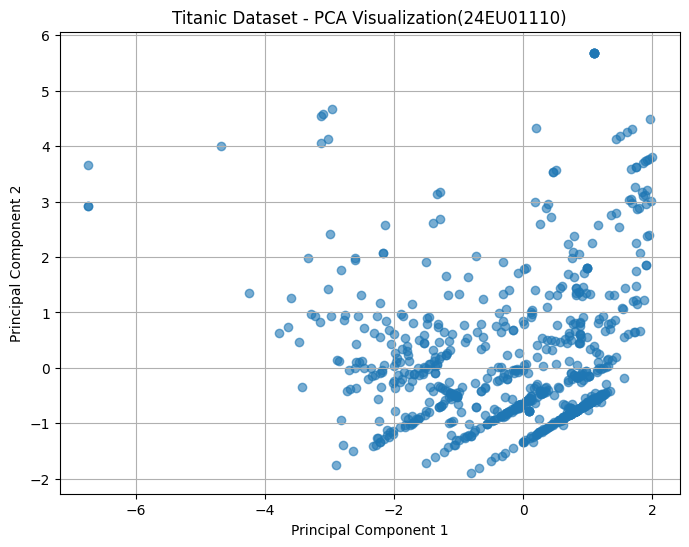

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Titanic Dataset - PCA Visualization(24EU01110)")
plt.grid()
plt.show()

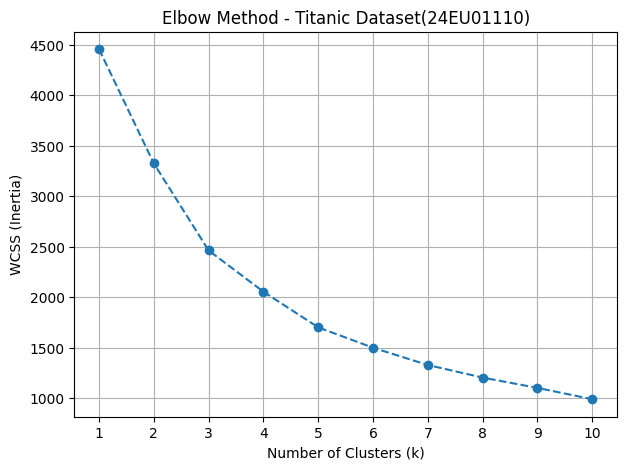

In [ ]:
wcss = []

k_range = range(1, 11)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(7, 5))

plt.plot(
    k_range,
    wcss,
    marker='o',
    linestyle='--'
)

plt.title("Elbow Method - Titanic Dataset(24EU01110)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)

plt.grid()
plt.show()

k = 2 -> Silhouette Score = 0.3758
k = 3 -> Silhouette Score = 0.4170
k = 4 -> Silhouette Score = 0.4136
k = 5 -> Silhouette Score = 0.4289


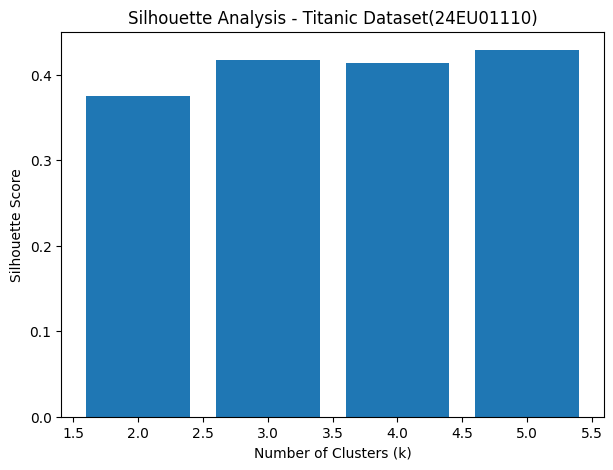


Best k = 5 with Silhouette Score = 0.4289


In [ ]:
silhouette_scores = []

k_eval = range(2, 6)

for k in k_eval:

    kmeans_temp = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    labels_temp = kmeans_temp.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels_temp
    )

    silhouette_scores.append(score)


for k, score in zip(k_eval, silhouette_scores):
    print(f"k = {k} -> Silhouette Score = {score:.4f}")


plt.figure(figsize=(7, 5))

plt.bar(
    k_eval,
    silhouette_scores
)

plt.title("Silhouette Analysis - Titanic Dataset(24EU01110)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.show()

best_k = k_eval[np.argmax(silhouette_scores)]

print(
    f"\nBest k = {best_k} "
    f"with Silhouette Score = {max(silhouette_scores):.4f}"
)

In [ ]:
kmeans_raw = KMeans(
    n_clusters=best_k,
    init='k-means++',
    random_state=42,
    n_init=10
)

kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)

# Add cluster labels to dataframe
titanic_data['cluster'] = kmeans_raw_labels

print("K-Means clustering completed.")

print("\nFirst 10 Cluster Assignments:")
print(titanic_data.head(10))

K-Means clustering completed.

First 10 Cluster Assignments:
   pclass   age  sibsp  parch     fare  cluster
0       3  22.0      1      0   7.2500        0
1       1  38.0      1      0  71.2833        1
2       3  26.0      0      0   7.9250        0
3       1  35.0      1      0  53.1000        1
4       3  35.0      0      0   8.0500        0
5       3  28.0      0      0   8.4583        0
6       1  54.0      0      0  51.8625        1
7       3   2.0      3      1  21.0750        2
8       3  27.0      0      2  11.1333        4
9       2  14.0      1      0  30.0708        0


In [ ]:

centroids_scaled = kmeans_raw.cluster_centers_


centroids_original = scaler.inverse_transform(
    centroids_scaled
)


centroids_df = pd.DataFrame(
    centroids_original,
    columns=features
)

centroids_df.index = [
    f"Cluster_{i}"
    for i in range(best_k)
]

print("Cluster Centroids:")
print(centroids_df)

Cluster Centroids:
             pclass        age     sibsp     parch        fare
Cluster_0  2.802419  27.741935  0.211694  0.040323   11.562129
Cluster_1  1.218182  40.881818  0.372727  0.131818   50.158901
Cluster_2  3.000000  12.780488  4.536585  1.609756   38.327849
Cluster_3  1.000000  30.591250  0.718750  1.156250  229.689066
Cluster_4  2.392157  18.669118  0.686275  1.843137   29.438072


In [ ]:
kmeans_pca = KMeans(
    n_clusters=best_k,
    init='k-means++',
    random_state=42,
    n_init=10
)

kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)


pca_df['cluster'] = kmeans_pca_labels

print("K-Means clustering on PCA space completed.")

print("\nFirst 10 PCA Cluster Assignments:")
print(pca_df.head(10))

K-Means clustering on PCA space completed.

First 10 PCA Cluster Assignments:
        PC1       PC2  cluster
0  1.140660 -0.076520        0
1 -1.768445  0.133479        4
2  0.879196 -0.726606        0
3 -1.458103  0.071555        4
4  0.561252 -0.943713        0
5  0.802847 -0.771110        0
6 -2.225584 -0.956077        4
7  1.954231  2.396247        2
8  0.886957  0.812021        1
9  0.352428  0.348021        1


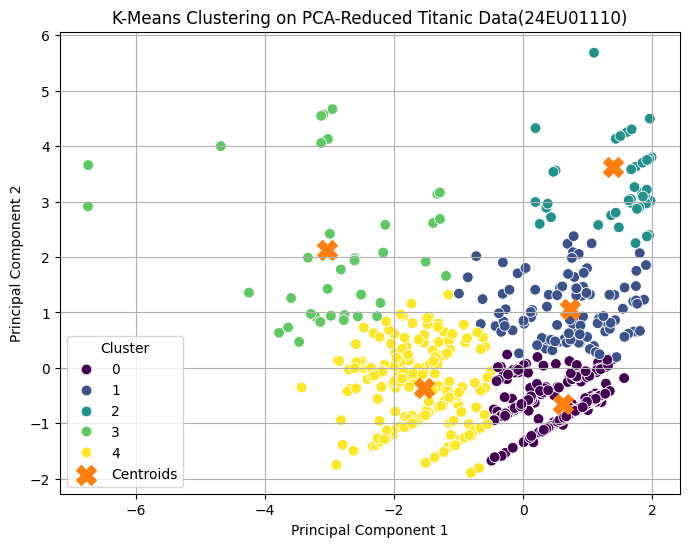

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans_pca_labels,
    palette='viridis',
    s=60
)


pca_centroids = kmeans_pca.cluster_centers_

plt.scatter(
    pca_centroids[:, 0],
    pca_centroids[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.title("K-Means Clustering on PCA-Reduced Titanic Data(24EU01110)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid()

plt.show()

In [ ]:
silhouette_raw = silhouette_score(
    X_scaled,
    kmeans_raw_labels
)

silhouette_pca = silhouette_score(
    X_pca,
    kmeans_pca_labels
)

print("========================================")
print("CLUSTERING PERFORMANCE")
print("========================================")

print(
    f"Raw Standardized Space Silhouette Score: "
    f"{silhouette_raw:.4f}"
)

print(
    f"PCA Reduced Space Silhouette Score: "
    f"{silhouette_pca:.4f}"
)

CLUSTERING PERFORMANCE
Raw Standardized Space Silhouette Score: 0.4289
PCA Reduced Space Silhouette Score: 0.5211


In [ ]:
comparison = pd.DataFrame({
    "Method": [
        "Standardized Raw Features",
        "PCA Reduced Features"
    ],

    "Number of Features": [
        X_scaled.shape[1],
        X_pca.shape[1]
    ],

    "Silhouette Score": [
        silhouette_raw,
        silhouette_pca
    ]
})

print("\n========================================")
print("FINAL COMPARISON")
print("========================================")

print(comparison.round(4))


FINAL COMPARISON
                      Method  Number of Features  Silhouette Score
0  Standardized Raw Features                   5            0.4289
1       PCA Reduced Features                   2            0.5211
